In [29]:
import sys
sys.path.insert(0,'../scripts')
from pathlib import Path
from pycap_for_PESTPP_MOU import postprocess_MOU, prep_for_viz
import yaml

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import geopandas as gpd
import contextily as ctx

In [30]:
scenario_path = Path('../pycap_runs/pycap_pest')

configurations = ['depletion_q_baseline_0.0_1.0_0.01', 'depletion_q_Tmin10per_0.0_1.0_0.01', 'depletion_q_Tplus10per_0.0_1.0_0.01', 'depletion_q_Tmin1mag_0.0_1.0_0.01', 'depletion_q_Tplus1mag_0.0_1.0_0.01', 'depletion_q_Smin1mag_0.0_1.0_0.01', 'depletion_q_Smin10per_0.0_1.0_0.01', 'depletion_q_Splus10per_0.0_1.0_0.01']
baseline_configs = ['depletion_q_baseline_0.0_1.0_0.01', 'depletion_q_baselinev2_0.0_1.0_0.01', 'depletion_q_baselinev3_0.0_1.0_0.01', 'depletion_q_baselinev4_0.0_1.0_0.01', 'depletion_q_baselinev5_0.0_1.0_0.01', 'depletion_q_baselinev6_0.0_1.0_0.01', 'depletion_q_baselinev7_0.0_1.0_0.01']

In [31]:
# Get the pareto_final_df and dv_df for the scenario configurations
scen_df_list = []
scen_dv_list = []
for run_name in configurations:
    run_path = scenario_path / f"run_{run_name}"
    pareto_df = postprocess_MOU(run_name, run_path)
    pareto_df_final, dv_df =  prep_for_viz(pareto_df, 50, run_path, run_name, dollar_objective=False)
    pareto_df_final.insert(2, "Streamflow (cfs)", 8.6 - pareto_df_final["Depletion (cfs)"])
    scen_df_list.append(pareto_df_final)
    scen_dv_list.append(dv_df)

# Get the pareto_df_final and dv_df for the baseline configurations
baseline_df_list = []
baseline_dv_list = []
for run_name in baseline_configs:
    run_path = scenario_path / f"run_{run_name}"
    pareto_df = postprocess_MOU(run_name, run_path)
    pareto_df_final, dv_df =  prep_for_viz(pareto_df, 50, run_path, run_name, dollar_objective=False)
    pareto_df_final.insert(2, "Streamflow (cfs)", 8.6 - pareto_df_final["Depletion (cfs)"])
    baseline_df_list.append(pareto_df_final)
    baseline_dv_list.append(dv_df)

In [54]:
# Plot styling
# colors = ["red", "blue", "green", "orange", "purple", "cyan", "magenta", "yellow"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f"]
markers = ["o", "s", "D", "^", "v", "<", ">", "P"]

base_name_list = [name.split("_")[2] for name in baseline_configs]
scen_name_list = [name.split("_")[2] for name in configurations]

zoom = True

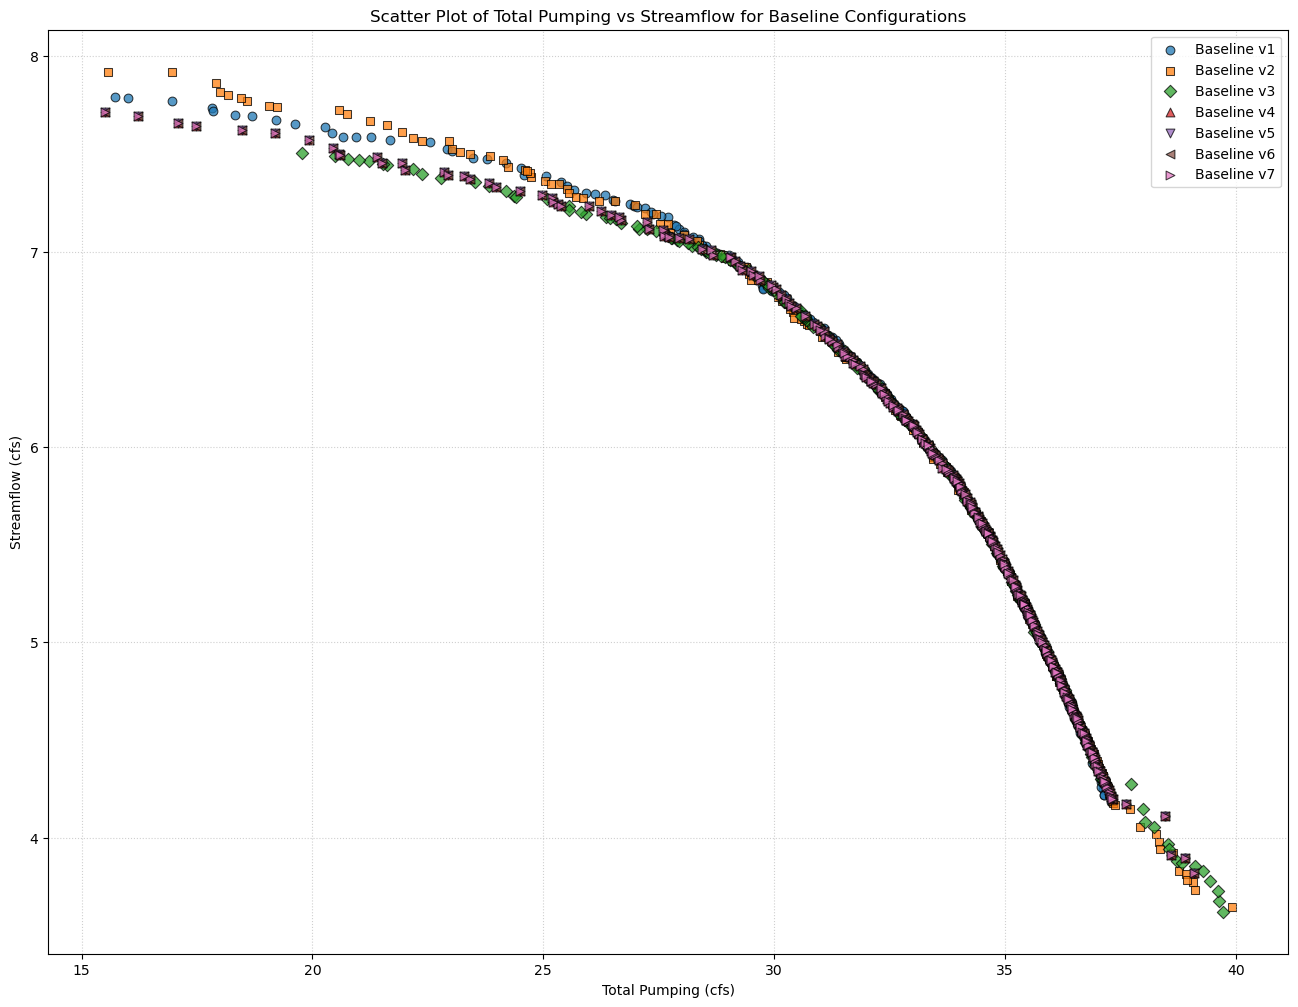

In [33]:
# Create a scatter plot of Total Pumping vs Streamflow for the baseline configurations
plt.figure(figsize=(16, 12))
for i, baseline_df in enumerate(baseline_df_list):
    plt.scatter(baseline_df["Total Pumping (cfs)"], baseline_df["Streamflow (cfs)"], marker=markers[i], s=80 if zoom else 40, color=colors[i], edgecolors="black", linewidths=0.75, alpha=0.75, label=f'Baseline v{i + 1}')
plt.xlabel("Total Pumping (cfs)")
plt.ylabel("Streamflow (cfs)")
plt.title("Scatter Plot of Total Pumping vs Streamflow for Baseline Configurations")
if zoom:
    plt.xlim(25, 34)
    plt.ylim(6, 7.5)
    # plt.xlim(30, 35)
    # plt.ylim(6, 7)
    # plt.xlim(20, 25)
    # plt.ylim(7, 8)
plt.grid(linestyle=":", alpha=0.6)
plt.legend()
plt.show()

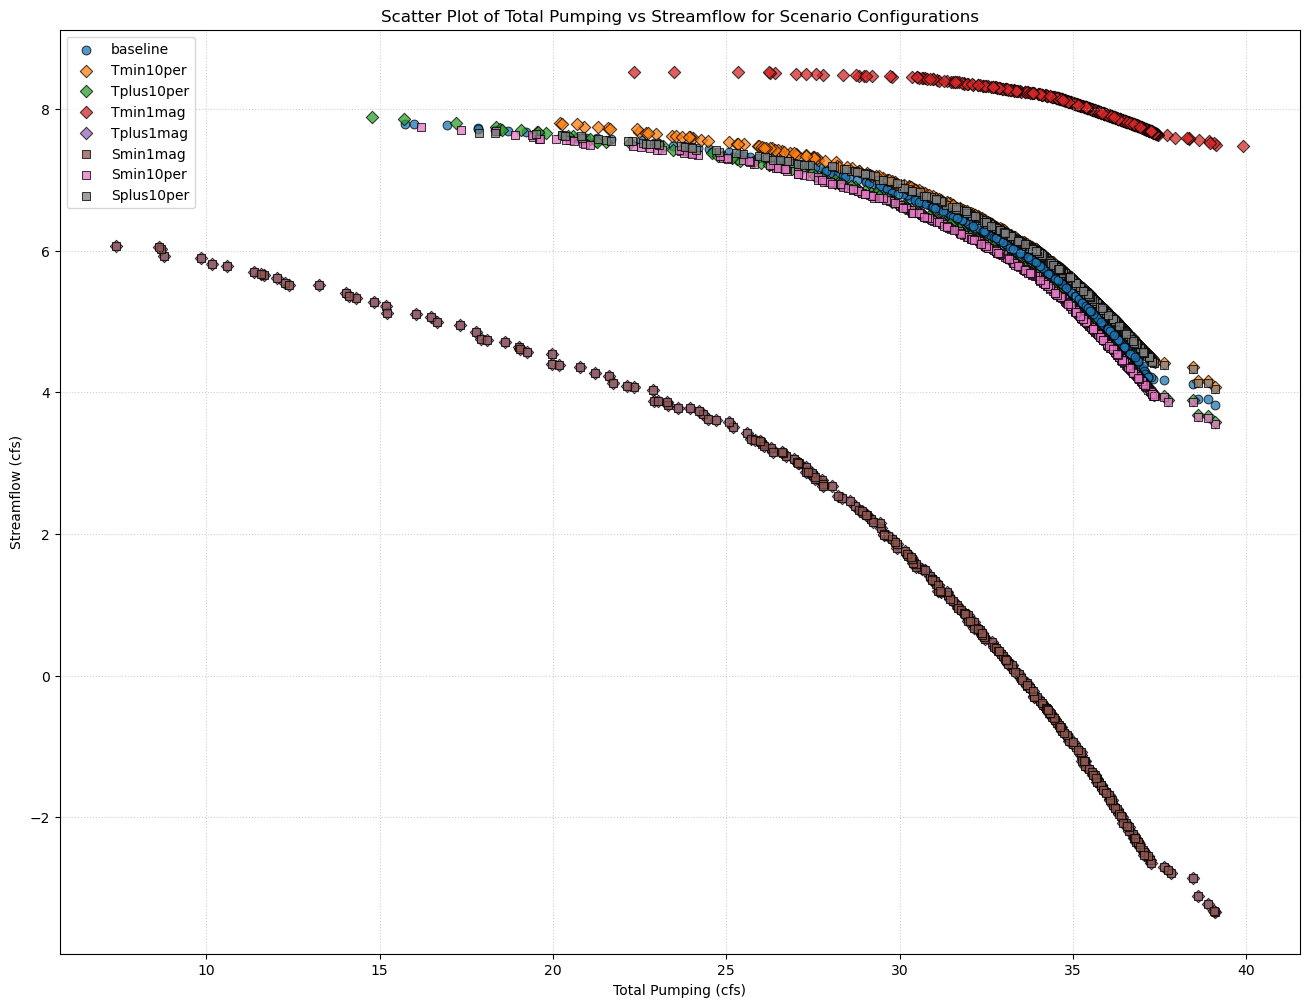

In [34]:
# Create a scatter plot of Total Pumping vs Streamflow for the scenario configurations
plt.figure(figsize=(16, 12))
for i, scen_df in enumerate(scen_df_list):
    m = 0 if "baseline" in scen_name_list[i] else 1 if 's'.upper() in scen_name_list[i] else 2
    plt.scatter(scen_df["Total Pumping (cfs)"], scen_df["Streamflow (cfs)"], marker=markers[m], s=80 if zoom else 40, color=colors[i], edgecolors="black", linewidths=0.75, alpha=0.75, label=f'{scen_name_list[i]}')
plt.xlabel("Total Pumping (cfs)")
plt.ylabel("Streamflow (cfs)")
plt.title("Scatter Plot of Total Pumping vs Streamflow for Scenario Configurations")
if zoom:
    plt.xlim(25, 35)
    plt.ylim(3, 9)
plt.grid(linestyle=":", alpha=0.6)
plt.legend()
plt.show()

In [35]:
scen_df_list[0].columns

Index(['generation', 'member', 'Streamflow (cfs)', 'Depletion (cfs)',
       'Total Pumping (cfs)', 'nsga2_front', 'nsga2_crowding_distance',
       'spea2_unconstrained_fitness', 'spea2_constrained_fitness',
       'is_feasible', 'feasible_distance'],
      dtype='str')

In [36]:
print(len(scen_df_list[0]["Total Pumping (cfs)"]))

296


In [37]:
scen_df_list[0].head(5)

,generation,member,Streamflow (cfs),Depletion (cfs),Total Pumping (cfs),nsga2_front,nsga2_crowding_distance,spea2_unconstrained_fitness,spea2_constrained_fitness,is_feasible,feasible_distance
8495,50,152,3.817420,4.782580,39.085358,1,1.000000e+30,0.001007,0.001007,1,-999
8496,50,gen=36_member=6021_pso,7.788917,0.811083,15.730438,1,1.000000e+30,0.000306,0.000306,1,-999
8497,50,16,4.110730,4.489270,38.467534,1,6.652770e-02,0.001397,0.001397,1,-999
8498,50,130,3.909290,4.690710,38.600100,1,5.337900e-02,0.001290,0.001290,1,-999
8499,50,95,3.898730,4.701270,38.900657,1,2.313270e-02,0.001099,0.001099,1,-999


In [38]:
scen_dv_list[0].T.columns

Index(['well_1013', 'well_1302', 'well_1323', 'well_1486', 'well_1584',
       'well_1589', 'well_1643', 'well_1683', 'well_1860', 'well_23610',
       ...
       'well_93143', 'well_93349', 'well_93422', 'well_93423', 'well_93424',
       'well_93469', 'well_93832', 'well_94302', 'well_94988', 'well_95068'],
      dtype='str', length=327)

In [39]:
scen_dv_list[0].T.tail(5)

,well_1013,well_1302,well_1323,well_1486,well_1584,well_1589,well_1643,well_1683,well_1860,well_23610,...,well_93143,well_93349,well_93422,well_93423,well_93424,well_93469,well_93832,well_94302,well_94988,well_95068
gen=50_member=8550_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=50_member=8507_pso,1.0,1.0,1.0,0.989241,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.826653,1.0,1.0
gen=50_member=8467_pso,1.0,1.0,1.0,0.658858,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=50_member=8487_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
geometry,POINT (-89.3453883 44.4873217),POINT (-89.4539046 44.5813718),POINT (-89.4508899 44.5219167),POINT (-89.4608233 44.5039967),POINT (-89.4647217 44.48),POINT (-89.4091941 44.4051847),POINT (-89.5335333 44.4174),POINT (-89.4090453 44.3906543),POINT (-89.4486378 44.5302783),POINT (-89.4409533 44.4574733),...,POINT (-89.528487 44.450128),POINT (-89.50594 44.41965),POINT (-89.30981 44.47068),POINT (-89.31012 44.4719),POINT (-89.31082 44.47132),POINT (-89.4464 44.4697),POINT (-89.2977 44.4647),POINT (-89.4835 44.4976),POINT (-89.396869 44.545632),POINT (-89.4462 44.4198)


In [40]:
maxQp = max([df["Total Pumping (cfs)"].max() for df in baseline_df_list])
minQp = min([df["Total Pumping (cfs)"].min() for df in baseline_df_list])
maxSf = max([df["Streamflow (cfs)"].max() for df in baseline_df_list])
minSf = min([df["Streamflow (cfs)"].min() for df in baseline_df_list])
print(f"Total Pumping (cfs) range across all configurations: {minQp:.2f} - {maxQp:.2f}")
print(f"Streamflow (cfs) range across all configurations: {minSf:.2f} - {maxSf:.2f}")

Total Pumping (cfs) range across all configurations: 15.50 - 39.91
Streamflow (cfs) range across all configurations: 3.62 - 7.92


In [41]:
# Flatten all pumping values into one array
all_Qp = np.concatenate([df["Total Pumping (cfs)"].values 
                         for df in baseline_df_list])

# Flatten all streamflow values
all_Sf = np.concatenate([df["Streamflow (cfs)"].values 
                         for df in baseline_df_list])


In [42]:
# bins_Qp = np.arange(minQp, maxQp + 1, 0.25)
# bins_Sf = np.arange(minSf, maxSf + 0.1, 0.05)

bins_Qp = np.arange(minQp, maxQp + 1, 0.2)
bins_Sf = np.arange(minSf, maxSf + 0.1, 0.05)


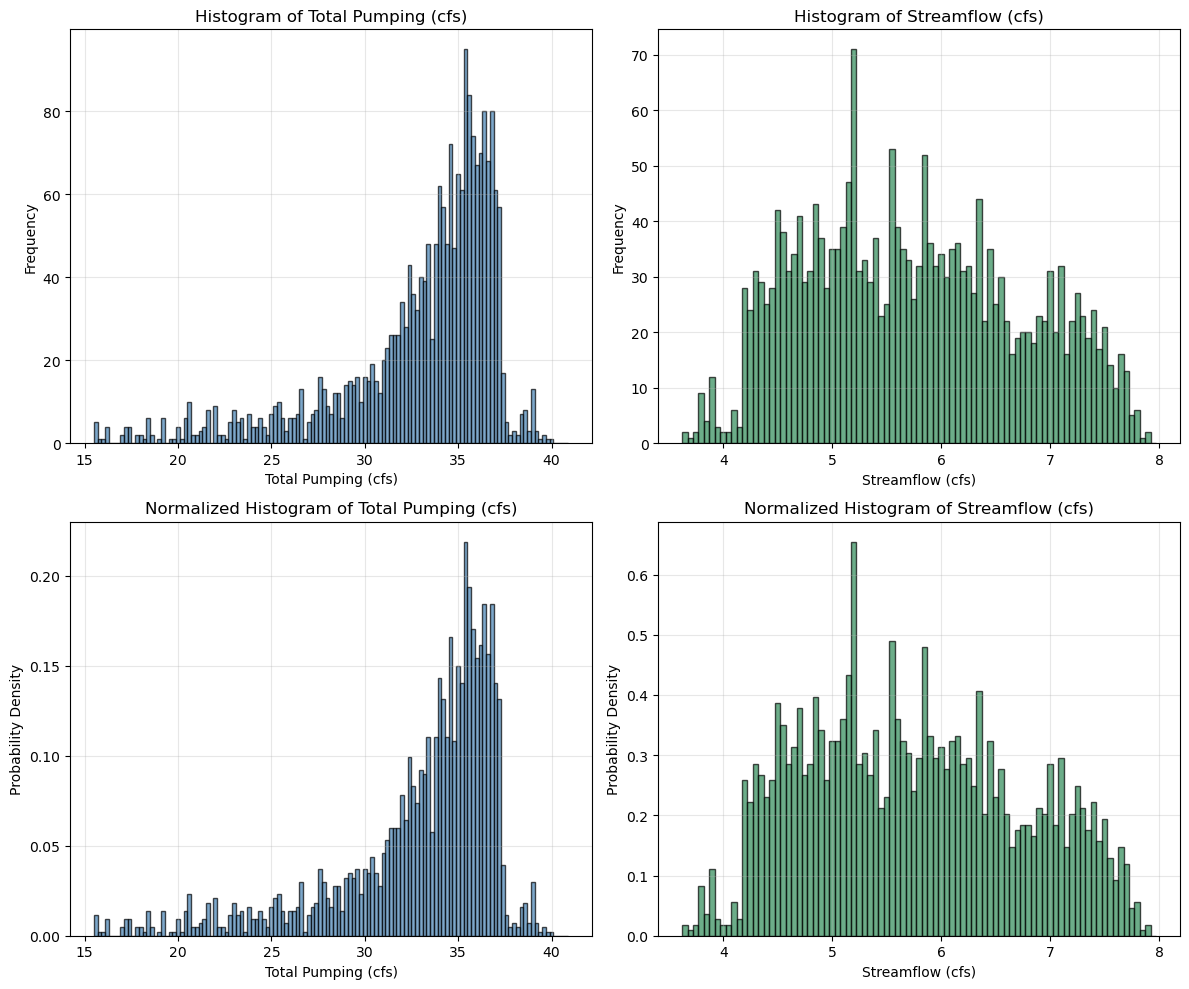

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Pumping histogram ---
axes[0, 0].hist(all_Qp, bins=bins_Qp, color="steelblue",
             edgecolor="black", alpha=0.7)
axes[0, 0].set_xlabel("Total Pumping (cfs)")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].set_title("Histogram of Total Pumping (cfs)")
axes[0, 0].grid(alpha=0.3)

# --- Streamflow histogram ---
axes[0, 1].hist(all_Sf, bins=bins_Sf, color="seagreen",
             edgecolor="black", alpha=0.7)
axes[0, 1].set_xlabel("Streamflow (cfs)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("Histogram of Streamflow (cfs)")
axes[0, 1].grid(alpha=0.3)

# --- Pumping histogram (normalized) ---
axes[1, 0].hist(all_Qp, bins=bins_Qp, density=True,
             color="steelblue", edgecolor="black", alpha=0.7)
axes[1, 0].set_xlabel("Total Pumping (cfs)")
axes[1, 0].set_ylabel("Probability Density")
axes[1, 0].set_title("Normalized Histogram of Total Pumping (cfs)")
axes[1, 0].grid(alpha=0.3)

# --- Streamflow histogram (normalized) ---
axes[1, 1].hist(all_Sf, bins=bins_Sf, density=True,
             color="seagreen", edgecolor="black", alpha=0.7)
axes[1, 1].set_xlabel("Streamflow (cfs)")
axes[1, 1].set_ylabel("Probability Density")
axes[1, 1].set_title("Normalized Histogram of Streamflow (cfs)")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


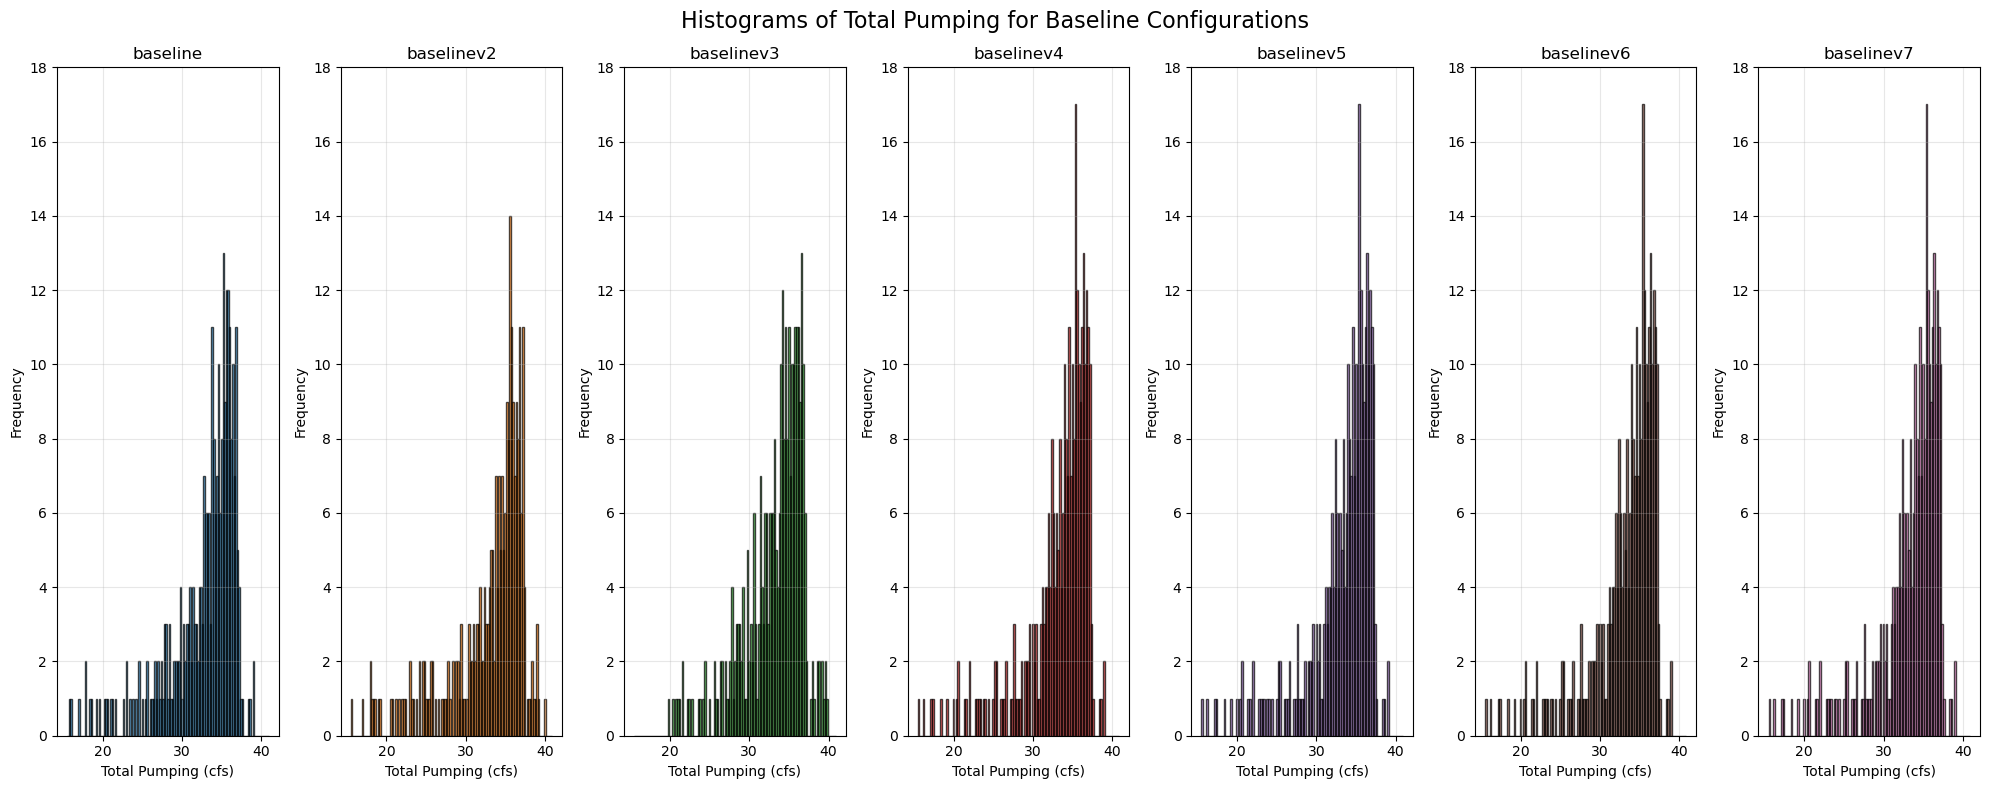

In [44]:
fig, axes = plt.subplots(1, len(baseline_df_list), figsize=(20, 8))
for i, baseline_df in enumerate(baseline_df_list):
    axes[i].hist(baseline_df["Total Pumping (cfs)"], bins=bins_Qp, color=colors[i], edgecolor="black", alpha=0.7)
    axes[i].set_xlabel("Total Pumping (cfs)")
    axes[i].set_ylabel("Frequency")
    axes[i].set_title(f"{base_name_list[i]}")
    axes[i].grid(alpha=0.3)
    axes[i].set_ylim(0, 18)
plt.suptitle("Histograms of Total Pumping for Baseline Configurations", fontsize=16)
plt.tight_layout()
plt.show()

In [45]:
# Count non-1.0 values for each well column
dfT = scen_dv_list[0].T

data_only = dfT.iloc[:-1]      # all rows except geometry
geometry = dfT.iloc[-1]        # geometry row
non1_counts = (data_only != 1.0).sum()

summary = pd.DataFrame({
    "non1_count": non1_counts,
    "geometry": geometry
})

summary


,non1_count,geometry
well_1013,0,POINT (-89.3453883 44.4873217)
well_1302,0,POINT (-89.4539046 44.5813718)
well_1323,0,POINT (-89.4508899 44.5219167)
well_1486,72,POINT (-89.4608233 44.5039967)
well_1584,20,POINT (-89.4647217 44.48)
...,...,...
well_93469,56,POINT (-89.4464 44.4697)
well_93832,0,POINT (-89.2977 44.4647)
well_94302,55,POINT (-89.4835 44.4976)
well_94988,0,POINT (-89.396869 44.545632)


In [46]:
summaries = []

for i, df in enumerate(baseline_dv_list, start=1):
    dfT = df.T
    
    data_only = dfT.iloc[:-1]      # numeric pumping values
    geometry = dfT.iloc[-1]        # geometry row
    
    non1_counts = (data_only != 1.0).sum()
    
    # Build a DataFrame indexed by well IDs
    summary = pd.DataFrame({
        "non1_count": non1_counts,
        "geometry": geometry.loc[non1_counts.index],
        "model": i
    })
    
    # MultiIndex: (well, model)
    summary.index = pd.MultiIndex.from_product(
        [non1_counts.index, [i]],
        names=["well", "model_idx"]
    )
    
    summaries.append(summary)

all_summaries = pd.concat(summaries)


### Fixed well-change summary and mapping cells
The cells below summarize how often each well's pumping value differs from 1.0 across the baseline runs. They use `all_summaries.reset_index()` before pivoting so `well` and `model_idx` are available as columns.

In [47]:
# Pivot the long summary table so each row is a well and each column is a baseline model.
# The previous version used df.pivot(...), but df was still the last dv_df from the loop.
# Here, "well" and "model_idx" are index levels in all_summaries, so reset_index() first.
summary_long = all_summaries.reset_index()

wide = (
    summary_long
    .pivot_table(
        index="well",
        columns="model_idx",
        values="non1_count",
        aggfunc="first"
    )
    .sort_index()
)

wide.head()


model_idx,1,2,3,4,5,6,7
well,,,,,,,
well_1013,0,0,0,0,0,0,0
well_1302,0,0,0,0,0,0,0
well_1323,0,0,0,0,0,0,0
well_1486,72,31,27,14,14,14,14
well_1584,20,12,14,99,99,99,99


In [48]:
# Identify wells that never change, and wells that change in most baseline models.
never_change = wide.eq(0).all(axis=1)
wells_never_change = wide.index[never_change]

n_models = wide.shape[1]
change_counts = wide.gt(0).sum(axis=1)

wells_change_most = change_counts[change_counts > n_models * 0.5].index

print(f"Number of wells: {wide.shape[0]}")
print(f"Number of baseline models: {n_models}")
print(f"Wells that never change: {len(wells_never_change)}")
print(f"Wells that change in more than half of baseline models: {len(wells_change_most)}")


Number of wells: 327
Number of baseline models: 7
Wells that never change: 233
Wells that change in more than half of baseline models: 94


In [49]:
# Build a per-well summary for mapping.
# Keep a column named non1_count so the plotting cells below still work.
# Here, non1_count is the mean number of non-1 pumping values across the baseline runs.
geometry_by_well = (
    summary_long
    .drop_duplicates(subset="well")
    .set_index("well")["geometry"]
)

map_df = pd.DataFrame({
    "non1_count": wide.mean(axis=1),            # used by the plotting cells below
    "mean_changes": wide.mean(axis=1),
    "max_changes": wide.max(axis=1),
    "n_models_changed": change_counts,
    "never_change": never_change,
    "change_in_most_models": change_counts > n_models * 0.5,
    "geometry": geometry_by_well.reindex(wide.index)
})

map_df.sample(25)


,non1_count,mean_changes,max_changes,n_models_changed,never_change,change_in_most_models,geometry
well,,,,,,,
well_92696,0.000000,0.000000,0,0,True,False,POINT (-89.28806 44.45703)
well_23778,0.000000,0.000000,0,0,True,False,POINT (-89.5131489 44.4141763)
well_23716,0.000000,0.000000,0,0,True,False,POINT (-89.4537432 44.5377989)
well_67673,0.000000,0.000000,0,0,True,False,POINT (-89.48496 44.4162767)
well_23929,63.857143,63.857143,68,7,False,True,POINT (-89.497971 44.483385)
well_23980,0.000000,0.000000,0,0,True,False,POINT (-89.441812 44.405113)
well_68872,0.000000,0.000000,0,0,True,False,POINT (-89.514335 44.428577)
well_23939,29.285714,29.285714,49,7,False,True,POINT (-89.4519934 44.4849817)
well_1584,63.142857,63.142857,99,7,False,True,POINT (-89.4647217 44.48)


In [50]:
# Convert the per-well summary to a GeoDataFrame.
# This uses map_df, not the temporary summary variable from the last loop iteration.
gdf = gpd.GeoDataFrame(
    map_df.reset_index(),
    geometry="geometry",
    crs="EPSG:4326"   # POINT coordinates appear to be lon/lat
)

# Drop any rows without geometry before mapping.
gdf = gdf.dropna(subset=["geometry"]).copy()

# Extract coordinates for plotting.
gdf["x"] = gdf.geometry.x
gdf["y"] = gdf.geometry.y

basemaps = [
    ctx.providers.CartoDB.Positron,
    ctx.providers.CartoDB.PositronNoLabels,
    ctx.providers.CartoDB.Voyager,
    ctx.providers.CartoDB.DarkMatter,
    ctx.providers.OpenStreetMap.Mapnik,
    ctx.providers.Esri.WorldStreetMap,
    ctx.providers.Esri.WorldTopoMap,
    ctx.providers.Esri.WorldImagery,
    ctx.providers.OpenTopoMap
]

# # Reproject only for basemap extent if needed:
# gdf_web = gdf.to_crs(epsg=3857)


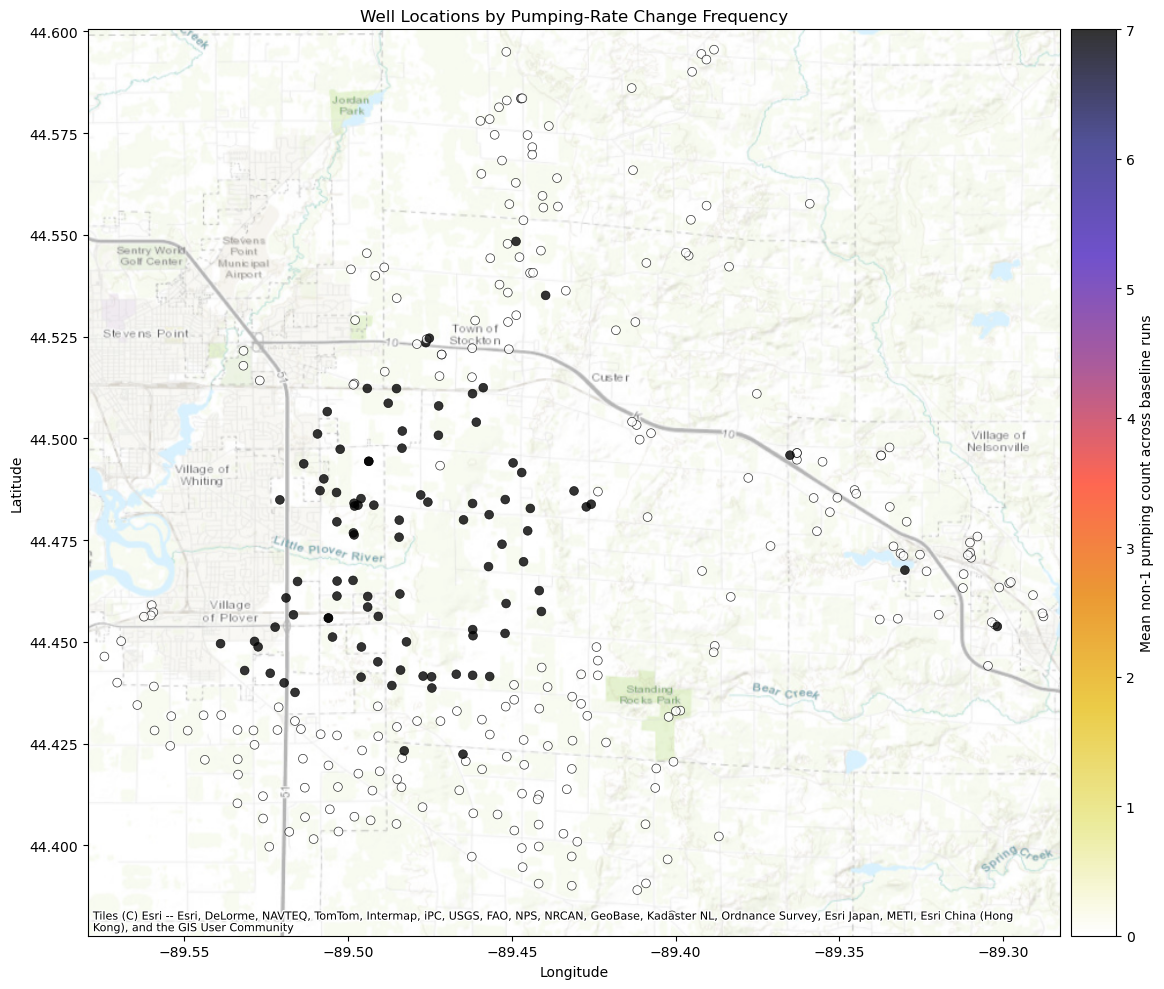

In [55]:
fig, ax = plt.subplots(figsize=(12, 10))

# Plot wells in original lon/lat.
sc = ax.scatter(
    gdf.geometry.x, gdf.geometry.y,
    c=gdf["n_models_changed"], # non1_count
    cmap="CMRmap_r",
    s=40,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.80
)

# Add basemap.
ctx.add_basemap(
    ax,
    source=basemaps[6],     # swap index to try others
    crs="EPSG:4326",        # scatter is in lon/lat
    alpha=0.75
)

# Set lon/lat limits.
ax.set_xlim(gdf.geometry.x.min() - 0.005, gdf.geometry.x.max() + 0.005)
ax.set_ylim(gdf.geometry.y.min() - 0.005, gdf.geometry.y.max() + 0.005)

# Colorbar.
cbar = plt.colorbar(sc, ax=ax, fraction=0.1, pad=0.01)
cbar.set_label("Mean non-1 pumping count across baseline runs")

ax.set_title("Well Locations by Pumping-Rate Change Frequency")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()


In [52]:
# Classify wells by the mapped non1_count value.
# Keep the upper bin dynamic so pd.cut does not fail when the maximum is below/above 100.
upper_bin = max(101, int(np.ceil(gdf["non1_count"].max())) + 1)
bins = [0, 5, 10, 25, 50, 100, upper_bin]
labels = ["0–5", "5–10", "10–25", "25–50", "50–100", "100+"]

gdf["bin"] = pd.cut(gdf["non1_count"], bins=bins, labels=labels, right=False, include_lowest=True)

bin_colors = {
    "0–5": "#888888",     # gray
    "5–10": "#33a02c",    # green
    "10–25": "#fdbf6f",   # orange
    "25–50": "#ff7f00",   # dark orange
    "50–100": "#e31a1c",  # red
    "100+": "#800000"     # dark red
}


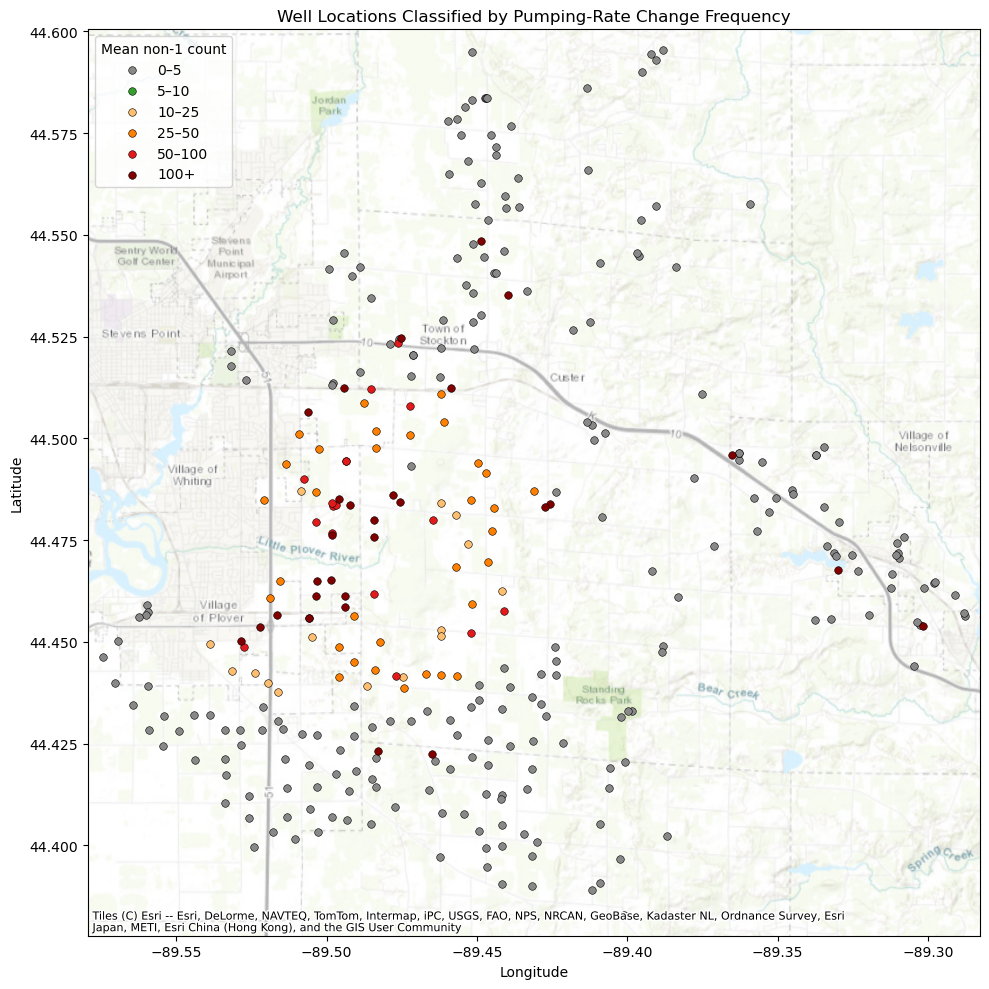

In [53]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot each category separately for a clean legend.
for category, color in bin_colors.items():
    subset = gdf[gdf["bin"] == category]
    ax.scatter(
        subset.geometry.x, subset.geometry.y,
        s=30,
        color=color,
        edgecolor="black",
        linewidth=0.4,
        label=category
    )

# Add basemap.
ctx.add_basemap(
    ax,
    source=basemaps[6],   # swap index to try others
    crs="EPSG:4326",
    alpha=0.75
)

# Set lon/lat limits.
ax.set_xlim(gdf.geometry.x.min() - 0.005, gdf.geometry.x.max() + 0.005)
ax.set_ylim(gdf.geometry.y.min() - 0.005, gdf.geometry.y.max() + 0.005)

# Legend.
ax.legend(title="Mean non-1 count", loc="upper left")

ax.set_title("Well Locations Classified by Pumping-Rate Change Frequency")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()
